In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, ttest_ind
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.multitest import multipletests
import pymc as pm
import arviz as az

In [2]:
control=pd.read_csv('control_group.csv')
test=pd.read_csv('test_group.csv')

In [3]:
control.head()

,Campaign Name;Date;Spend [USD];# of Impressions;Reach;# of Website Clicks;# of Searches;# of View Content;# of Add to Cart;# of Purchase
0,Control Campaign;1.08.2019;2280;82702;56930;70...
1,Control Campaign;2.08.2019;1757;121040;102513;...
2,Control Campaign;3.08.2019;2343;131711;110862;...
3,Control Campaign;4.08.2019;1940;72878;61235;30...
4,Control Campaign;5.08.2019;1835;;;;;;;


In [4]:
columns_list = control.columns[0].split(';')
data = list(control["Campaign Name;Date;Spend [USD];# of Impressions;Reach;# of Website Clicks;# of Searches;# of View Content;# of Add to Cart;# of Purchase"].apply(lambda x: x.split(';')))

In [5]:
control_group = pd.DataFrame(data, columns=columns_list)
control_group['Date'] = pd.to_datetime(control_group['Date'],format='%d.%m.%Y')
control_group.head()

,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Control Campaign,2019-08-01,2280,82702,56930,7016,2290,2159,1819,618
1,Control Campaign,2019-08-02,1757,121040,102513,8110,2033,1841,1219,511
2,Control Campaign,2019-08-03,2343,131711,110862,6508,1737,1549,1134,372
3,Control Campaign,2019-08-04,1940,72878,61235,3065,1042,982,1183,340
4,Control Campaign,2019-08-05,1835,,,,,,,


In [6]:
control_group.describe()

,Date
count,30
mean,2019-08-15 12:00:00
min,2019-08-01 00:00:00
25%,2019-08-08 06:00:00
50%,2019-08-15 12:00:00
75%,2019-08-22 18:00:00
max,2019-08-30 00:00:00


In [7]:
print(f"Number of rows={control_group.shape[0]}")
print(f"Number of columns={control_group.shape[1]}")

Number of rows=30
Number of columns=10


In [8]:
print(f"Number of missing values={control_group.isna().sum()}")
print(f"Number of duplicates={control_group.duplicated().sum()}")

Number of missing values=Campaign Name          0
Date                   0
Spend [USD]            0
# of Impressions       0
Reach                  0
# of Website Clicks    0
# of Searches          0
# of View Content      0
# of Add to Cart       0
# of Purchase          0
dtype: int64
Number of duplicates=0


In [9]:
test.head()

,Campaign Name;Date;Spend [USD];# of Impressions;Reach;# of Website Clicks;# of Searches;# of View Content;# of Add to Cart;# of Purchase
0,Test Campaign;1.08.2019;3008;39550;35820;3038;...
1,Test Campaign;2.08.2019;2542;100719;91236;4657...
2,Test Campaign;3.08.2019;2365;70263;45198;7885;...
3,Test Campaign;4.08.2019;2710;78451;25937;4216;...
4,Test Campaign;5.08.2019;2297;114295;95138;5863...


In [10]:
columns_list2=test.columns[0].split(';')
data2 = list(test["Campaign Name;Date;Spend [USD];# of Impressions;Reach;# of Website Clicks;# of Searches;# of View Content;# of Add to Cart;# of Purchase"].apply(lambda x: x.split(';')))

In [11]:
test_group = pd.DataFrame(data2, columns=columns_list2)
test_group['Date'] = pd.to_datetime(test_group['Date'],format='%d.%m.%Y')
test_group.head()

,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Test Campaign,2019-08-01,3008,39550,35820,3038,1946,1069,894,255
1,Test Campaign,2019-08-02,2542,100719,91236,4657,2359,1548,879,677
2,Test Campaign,2019-08-03,2365,70263,45198,7885,2572,2367,1268,578
3,Test Campaign,2019-08-04,2710,78451,25937,4216,2216,1437,566,340
4,Test Campaign,2019-08-05,2297,114295,95138,5863,2106,858,956,768


In [13]:
test_group.describe()

,Date
count,30
mean,2019-08-15 12:00:00
min,2019-08-01 00:00:00
25%,2019-08-08 06:00:00
50%,2019-08-15 12:00:00
75%,2019-08-22 18:00:00
max,2019-08-30 00:00:00


In [14]:
print(f"Number of rows={test_group.shape[0]}")
print(f"Number of columns={test_group.shape[1]}")

Number of rows=30
Number of columns=10


In [15]:
print(f"Number of missing values={test_group.isna().sum()}")
print(f"Number of duplicates={test_group.duplicated().sum()}")

Number of missing values=Campaign Name          0
Date                   0
Spend [USD]            0
# of Impressions       0
Reach                  0
# of Website Clicks    0
# of Searches          0
# of View Content      0
# of Add to Cart       0
# of Purchase          0
dtype: int64
Number of duplicates=0


In [16]:
print(control_group.groupby('Campaign Name')['Date'].agg(['min', 'max']))
print(test_group.groupby('Campaign Name')['Date'].agg(['min', 'max']))

                        min        max
Campaign Name                         
Control Campaign 2019-08-01 2019-08-30
                     min        max
Campaign Name                      
Test Campaign 2019-08-01 2019-08-30


In [17]:
print(control_group.dtypes)

Campaign Name                     str
Date                   datetime64[us]
Spend [USD]                       str
# of Impressions                  str
Reach                             str
# of Website Clicks               str
# of Searches                     str
# of View Content                 str
# of Add to Cart                  str
# of Purchase                     str
dtype: object


In [18]:
cols_to_convert = ['Spend [USD]', '# of Impressions', 'Reach', '# of Website Clicks',
                   '# of Searches', '# of View Content', '# of Add to Cart', '# of Purchase']

for col in cols_to_convert:
    control_group[col] = pd.to_numeric(control_group[col], errors='coerce')
    test_group[col]    = pd.to_numeric(test_group[col], errors='coerce')

print(control_group.dtypes)

Campaign Name                     str
Date                   datetime64[us]
Spend [USD]                     int64
# of Impressions              float64
Reach                         float64
# of Website Clicks           float64
# of Searches                 float64
# of View Content             float64
# of Add to Cart              float64
# of Purchase                 float64
dtype: object


In [19]:
print(f"Control total spend: ${control_group['Spend [USD]'].sum():,.2f}")
print(f"Test total spend:    ${test_group['Spend [USD]'].sum():,.2f}")

Control total spend: $68,653.00
Test total spend:    $76,892.00


In [20]:
df= pd.concat([control_group,test_group])

In [21]:
spend_col = 'Spend [USD]'
funnel_cols = ['# of Impressions', 'Reach', '# of Website Clicks','# of Searches',
               '# of View Content', '# of Add to Cart', '# of Purchase']
for col in funnel_cols:
    df[f'{col}_per_1k_spend'] = np.where(
        df['Spend [USD]'] > 0,                          #only dividing if spend>0
        (df[col]/df['Spend [USD]'])*1000,
        np.nan                                           #else mark as NaN
    )
print('Spend-normalised columns created')
df[['Campaign Name'] + [f'{c}_per_1k_spend' for c in funnel_cols]].groupby('Campaign Name').mean().round(2)

Spend-normalised columns created


,# of Impressions_per_1k_spend,Reach_per_1k_spend,# of Website Clicks_per_1k_spend,# of Searches_per_1k_spend,# of View Content_per_1k_spend,# of Add to Cart_per_1k_spend,# of Purchase_per_1k_spend
Campaign Name,,,,,,,
Control Campaign,48267.29,39168.31,2377.58,987.21,866.41,578.40,232.04
Test Campaign,29559.48,21236.66,2417.69,963.78,736.93,347.36,206.58


In [22]:
#Conversion funnel rates
funnel_agg = df.groupby('Campaign Name')[funnel_cols].sum()

# Conversion rates at each stage relative to impressions
funnel_rates = funnel_agg.div(funnel_agg['# of Impressions'], axis=0) * 100
print('Funnel Conversion Rates (% of Impressions)')
print(funnel_rates.round(3))

Funnel Conversion Rates (% of Impressions)
                  # of Impressions   Reach  # of Website Clicks  \
Campaign Name                                                     
Control Campaign             100.0  81.093                4.857   
Test Campaign                100.0  71.719                8.088   

                  # of Searches  # of View Content  # of Add to Cart  \
Campaign Name                                                          
Control Campaign          2.027              1.774             1.187   
Test Campaign             3.243              2.491             1.182   

                  # of Purchase  
Campaign Name                    
Control Campaign          0.477  
Test Campaign             0.699  


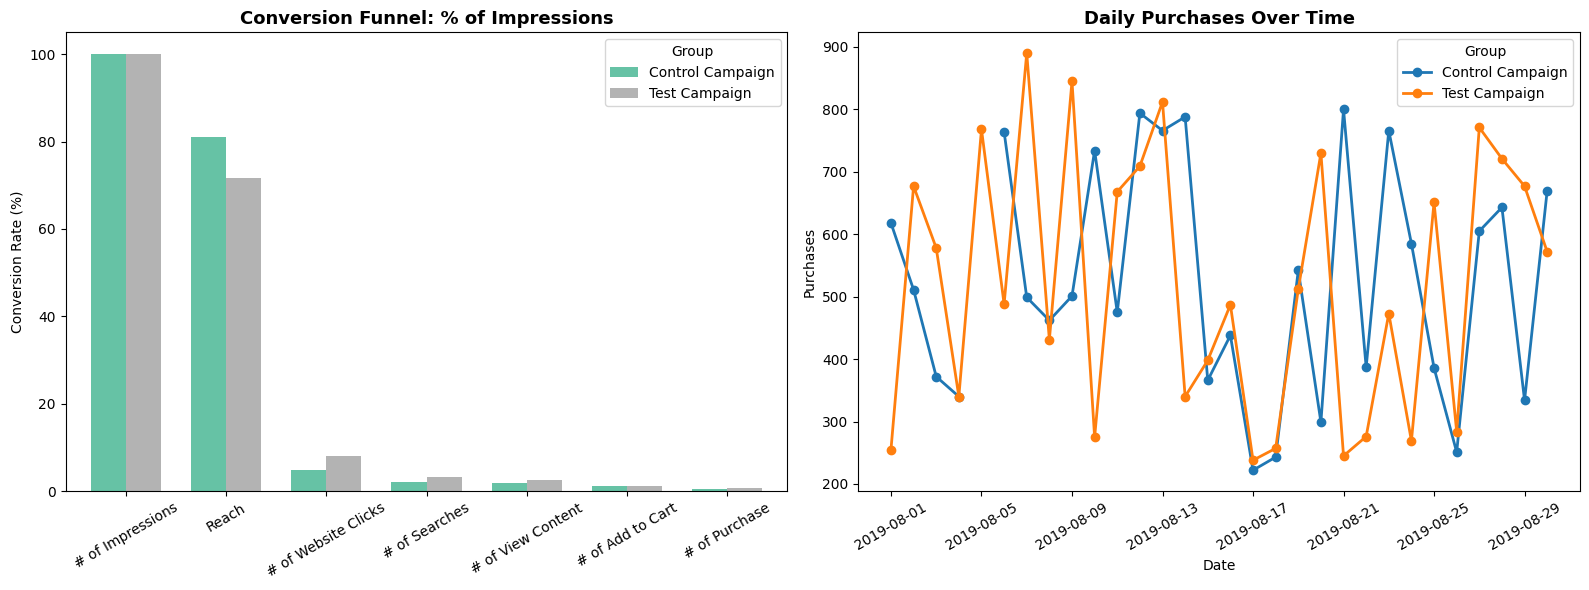

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Plot 1: Funnel bar chart
funnel_rates[funnel_cols].T.plot(kind='bar', ax=axes[0], colormap='Set2', width=0.7)
axes[0].set_title('Conversion Funnel: % of Impressions', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Group')

#Plot 2: Daily purchases over time
for grp, grp_df in df.groupby('Campaign Name'):
    axes[1].plot(grp_df['Date'], grp_df['# of Purchase'], marker='o', label=grp, linewidth=2)
axes[1].set_title('Daily Purchases Over Time', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Purchases')
axes[1].set_xlabel('Date')
axes[1].legend(title='Group')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('funnel_eda.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
#Stage-to-stage drop-off rates
stages = ['# of Impressions', '# of Website Clicks','# of Searches','# of View Content', '# of Add to Cart', '# of Purchase']
dropoff = {}
for grp, gdf in df.groupby('Campaign Name'):
    totals = gdf[stages].sum()
    rates  = [totals[stages[i+1]] / totals[stages[i]] * 100 for i in range(len(stages)-1)]
    dropoff[grp] = rates

dropoff_df = pd.DataFrame(dropoff,
    index=[f'{stages[i]}→{stages[i+1]}' for i in range(len(stages)-1)])
print('Stage-to-Stage Conversion Rates(%)')
print(dropoff_df.round(2))

Stage-to-Stage Conversion Rates(%)
                                      Control Campaign  Test Campaign
# of Impressions→# of Website Clicks              4.86           8.09
# of Website Clicks→# of Searches                41.75          40.10
# of Searches→# of View Content                  87.51          76.81
# of View Content→# of Add to Cart               66.88          47.45
# of Add to Cart→# of Purchase                   40.21          59.13


In [25]:
# Re-create control_df and test_df AFTER normalisation columns exist in df
control_df = df[df['Campaign Name'] == 'Control Campaign'].copy()
test_df    = df[df['Campaign Name'] == 'Test Campaign'].copy()

# Verify normalised columns are present
print(control_df['# of Purchase_per_1k_spend'].describe().round(2))
print(test_df['# of Purchase_per_1k_spend'].describe().round(2))

count     29.00
mean     232.04
std       91.27
min      101.98
25%      158.77
50%      216.40
75%      290.84
max      443.70
Name: # of Purchase_per_1k_spend, dtype: float64
count     30.00
mean     206.58
std       87.99
min       78.73
25%      129.55
50%      197.52
75%      268.46
max      411.76
Name: # of Purchase_per_1k_spend, dtype: float64


In [26]:
#Using Purchase as the primary metric(bottom-of-funnel, highest business value)
#We are treating daily purchase counts as our observations (n=30 per group)

#Primary metric: Purchase-per-1k-spend
baseline_mean = control_df['# of Purchase_per_1k_spend'].mean()
baseline_std  = control_df['# of Purchase_per_1k_spend'].std()

print(f'Control baseline (purchases per $1k spend): {baseline_mean:.2f} ± {baseline_std:.2f}')

#Minimum detectable effect:10% relative lift(business threshold)
MDE = 0.10*baseline_mean
effect_size_d = MDE/baseline_std   #Cohen's d

print(f'Minimum Detectable Effect (10% lift): {MDE:.2f}')
print(f'Cohen\'s d: {effect_size_d:.3f}')

#Required sample size
power_analysis = NormalIndPower()
required_n = power_analysis.solve_power(
    effect_size=effect_size_d,
    alpha=0.05,
    power=0.80,
    alternative='two-sided'
)

actual_n = len(control_df)
print(f'\nRequired n per group (80% power, α=0.05): {int(np.ceil(required_n))}')
print(f'Actual n per group: {actual_n}')

if actual_n >= required_n:
    print('Experiment is adequately powered.')
else:
    print(f'Experiment is UNDERPOWERED. Results should be interpreted with caution.')
    print(f'Actual power≈{power_analysis.solve_power(effect_size=effect_size_d, nobs1=actual_n, alpha=0.05):.2%}')

Control baseline (purchases per $1k spend): 232.04 ± 91.27
Minimum Detectable Effect (10% lift): 23.20
Cohen's d: 0.254

Required n per group (80% power, α=0.05): 243
Actual n per group: 30
Experiment is UNDERPOWERED. Results should be interpreted with caution.
Actual power≈16.63%


In [27]:
df.head()

,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase,# of Impressions_per_1k_spend,Reach_per_1k_spend,# of Website Clicks_per_1k_spend,# of Searches_per_1k_spend,# of View Content_per_1k_spend,# of Add to Cart_per_1k_spend,# of Purchase_per_1k_spend
0,Control Campaign,2019-08-01,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0,36272.807018,24969.298246,3077.192982,1004.385965,946.929825,797.807018,271.052632
1,Control Campaign,2019-08-02,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0,68890.153671,58345.475242,4615.822425,1157.085942,1047.808765,693.796244,290.836653
2,Control Campaign,2019-08-03,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0,56214.682032,47316.261204,2777.635510,741.357234,661.118224,483.994878,158.770807
3,Control Campaign,2019-08-04,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0,37565.979381,31564.432990,1579.896907,537.113402,506.185567,609.793814,175.257732
4,Control Campaign,2019-08-05,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
from scipy.stats import shapiro
results = []
metrics = [
    '# of Impressions_per_1k_spend',
    '# of Website Clicks_per_1k_spend',
    '# of Searches_per_1k_spend',
    '# of View Content_per_1k_spend',
    '# of Add to Cart_per_1k_spend',
    '# of Purchase_per_1k_spend'
]

for metric in metrics:
    c = control_df[metric].dropna()
    t = test_df[metric].dropna()

    #Normality check (Shapiro-Wilk)
    _, p_norm_c = shapiro(c)
    _, p_norm_t = shapiro(t)
    is_normal = (p_norm_c > 0.05) and (p_norm_t > 0.05)

    #Choosing test based on normality
    if is_normal:
        stat, p_val = ttest_ind(c, t, equal_var=False)   # Welch's t-test
        test_used = "Welch's t-test"
    else:
        stat, p_val = mannwhitneyu(c, t, alternative='two-sided')
        test_used = 'Mann-Whitney U'

    #Effect size: Cohen's d
    pooled_std = np.sqrt((c.std()**2 + t.std()**2) / 2)
    cohens_d   = (t.mean() - c.mean()) / pooled_std if pooled_std > 0 else 0

    results.append({
        'Metric': metric.replace('_per_1k_spend', '').replace('# of ', '').title(),
        'Control Mean': round(c.mean(), 2),
        'Test Mean':    round(t.mean(), 2),
        'Lift (%)':     round((t.mean() - c.mean()) / c.mean() * 100, 1),
        'Test Used':    test_used,
        'p-value':      round(p_val, 4),
        "Cohen's d":    round(cohens_d, 3),
        'Significant (α=0.05)': 'Yes' if p_val < 0.05 else 'No'
    })

results_df = pd.DataFrame(results)
print('Frequentist Test Results (raw p-values)')
results_df

Frequentist Test Results (raw p-values)


,Metric,Control Mean,Test Mean,Lift (%),Test Used,p-value,Cohen's d,Significant (α=0.05)
0,Impressions,48267.29,29559.48,-38.8,Welch's t-test,0.0000,-1.563,Yes
1,Website Clicks,2377.58,2417.69,1.7,Welch's t-test,0.8606,0.046,No
2,Searches,987.21,963.78,-2.4,Welch's t-test,0.7859,-0.072,No
3,View Content,866.41,736.93,-14.9,Welch's t-test,0.1256,-0.407,No
4,Add To Cart,578.40,347.36,-39.9,Welch's t-test,0.0000,-1.367,Yes
5,Purchase,232.04,206.58,-11.0,Welch's t-test,0.2801,-0.284,No


In [29]:
p_values = results_df['p-value'].values

#Bonferroni correction
reject_bonf, p_bonf, _, _ = multipletests(p_values, alpha=0.05, method='bonferroni')

#Benjamini-Hochberg (FDR) correction
reject_bh, p_bh, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

results_df['p(Bonferroni)'] = p_bonf.round(4)
results_df['Sig.(Bonferroni)'] = ['Yes' if r else 'No' for r in reject_bonf]
results_df['p(BH/FDR)'] = p_bh.round(4)
results_df['Sig.(BH)'] = ['Yes' if r else 'No' for r in reject_bh]

print('Results After Multiple Comparisons Correction')
results_df[['Metric', 'Lift (%)', 'p-value', 'p(Bonferroni)',
            'Sig.(Bonferroni)', 'p(BH/FDR)', 'Sig.(BH)']]

Results After Multiple Comparisons Correction


,Metric,Lift (%),p-value,p(Bonferroni),Sig.(Bonferroni),p(BH/FDR),Sig.(BH)
0,Impressions,-38.8,0.0000,0.0000,Yes,0.0000,Yes
1,Website Clicks,1.7,0.8606,1.0000,No,0.8606,No
2,Searches,-2.4,0.7859,1.0000,No,0.8606,No
3,View Content,-14.9,0.1256,0.7536,No,0.2512,No
4,Add To Cart,-39.9,0.0000,0.0000,Yes,0.0000,Yes
5,Purchase,-11.0,0.2801,1.0000,No,0.4202,No


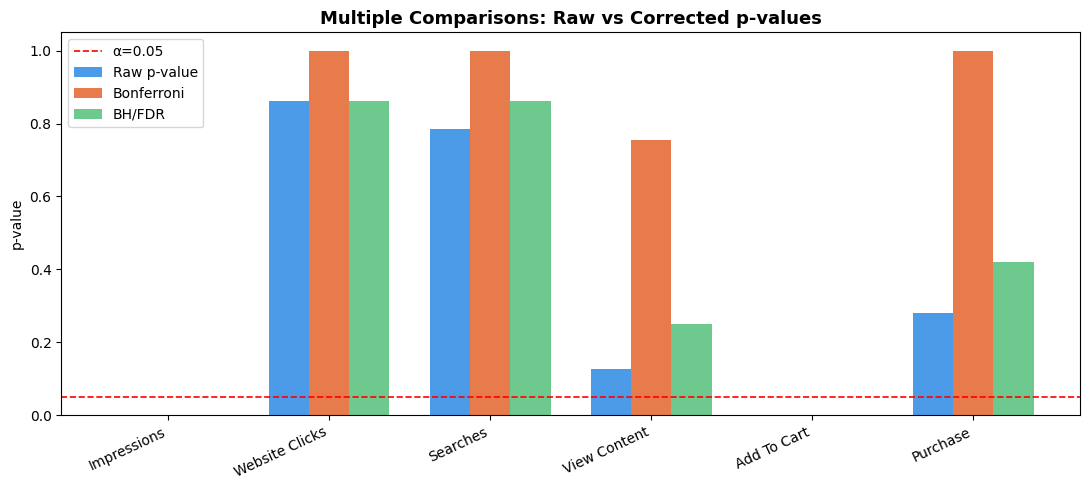

In [30]:
#Visualizing p-value comparison across corrections
fig, ax = plt.subplots(figsize=(11, 5))

x=np.arange(len(results_df))
w=0.25

ax.bar(x-w, results_df['p-value'],width=w, label='Raw p-value',color='#4C9BE8')
ax.bar(x,results_df['p(Bonferroni)'],width=w, label='Bonferroni',color='#E87B4C')
ax.bar(x+w, results_df['p(BH/FDR)'], width=w, label='BH/FDR',color='#6EC98F')

ax.axhline(0.05, color='red', linestyle='--', linewidth=1.2, label='α=0.05')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Metric'], rotation=25, ha='right')
ax.set_ylabel('p-value')
ax.set_title('Multiple Comparisons: Raw vs Corrected p-values', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('multiple_comparisons.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
#Primary metric: raw purchase counts per day
purchases_control=control_df['# of Purchase'].values
purchases_test=test_df['# of Purchase'].values

with pm.Model() as purchase_model:
    #Weakly informative Gamma priors on daily purchase rate
    lambda_control=pm.Gamma('lambda_control',alpha=2,beta=0.01)
    lambda_test=pm.Gamma('lambda_test',alpha=2,beta=0.01)

    #Likelihood: daily purchases follow a Poisson distribution
    obs_control=pm.Poisson('obs_control',mu=lambda_control,observed=purchases_control)
    obs_test=pm.Poisson('obs_test',mu=lambda_test,observed=purchases_test)

    #Derived quantities
    delta=pm.Deterministic('delta',lambda_test-lambda_control)
    rel_uplift=pm.Deterministic('rel_uplift',(lambda_test-lambda_control)/lambda_control)
    trace = pm.sample(4000, tune=2000, target_accept=0.95, return_inferencedata=True, progressbar=True)
print('Sampling complete')

c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\pymc\model\core.py:1304: RuntimeWarning: invalid value encountered in cast
  data = convert_observed_data(data).astype(rv_var.dtype)
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\pymc\model\core.py:1318: ImputationWarning: Data in obs_control contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\pytensor\link\c\cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mod

Output()

Sampling 4 chains for 2_000 tune and 4_000 draw iterations (8_000 + 16_000 draws total) took 22 seconds.


Sampling complete


In [32]:
#Key posterior quantities
delta_samples=trace.posterior['delta'].values.flatten()
uplift_samples=trace.posterior['rel_uplift'].values.flatten()

prob_test_better=(delta_samples>0).mean()
median_uplift=np.median(uplift_samples)*100
ci_low, ci_high=np.percentile(uplift_samples*100,[2.5,97.5])

print(f'P(Test campaign > Control):{prob_test_better:.1%}')
print(f'Median relative uplift:{median_uplift:.1f}%')
print(f'95% Credible Interval for uplift: [{ci_low:.1f}%, {ci_high:.1f}%]')
print('Interpretation:')
print(f'There is a {prob_test_better:.0%} posterior probability that the test campaign generates more purchases than the control campaign, with an estimated')
print(f'median uplift of {median_uplift:.1f}% (95% CI: {ci_low:.1f}% to {ci_high:.1f}%).')

P(Test campaign > Control):39.6%
Median relative uplift:-0.3%
95% Credible Interval for uplift: [-2.4%, 2.0%]
Interpretation:
There is a 40% posterior probability that the test campaign generates more purchases than the control campaign, with an estimated
median uplift of -0.3% (95% CI: -2.4% to 2.0%).


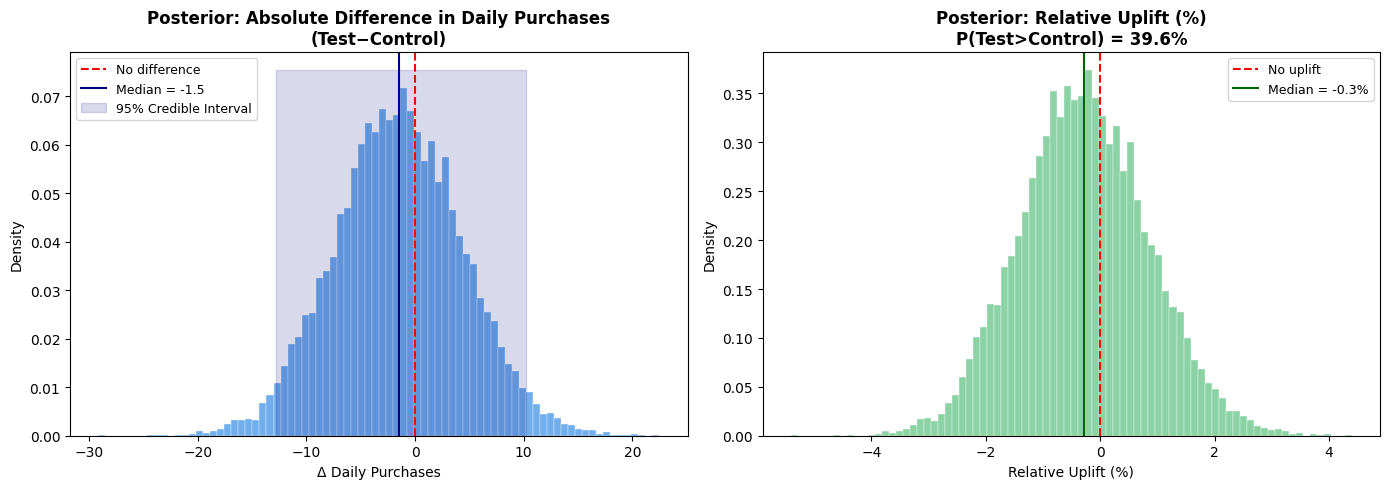

In [33]:
#Posterior distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Posterior of delta (absolute difference)
axes[0].hist(delta_samples, bins=80, color='#4C9BE8', alpha=0.8, density=True, edgecolor='white', linewidth=0.3)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='No difference')
axes[0].axvline(np.median(delta_samples), color='navy', linestyle='-', linewidth=1.5, label=f'Median = {np.median(delta_samples):.1f}')
axes[0].fill_betweenx(
    [0, axes[0].get_ylim()[1] if axes[0].get_ylim()[1]>0 else 1],
    np.percentile(delta_samples, 2.5),
    np.percentile(delta_samples, 97.5),
    alpha=0.15, color='navy', label='95% Credible Interval'
)
axes[0].set_title('Posterior: Absolute Difference in Daily Purchases\n(Test−Control)', fontweight='bold')
axes[0].set_xlabel('Δ Daily Purchases')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9)

# Plot 2: Posterior of relative uplift
axes[1].hist(uplift_samples * 100, bins=80, color='#6EC98F', alpha=0.8, density=True, edgecolor='white', linewidth=0.3)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='No uplift')
axes[1].axvline(median_uplift, color='darkgreen', linestyle='-', linewidth=1.5, label=f'Median = {median_uplift:.1f}%')
axes[1].set_title(f'Posterior: Relative Uplift (%)\nP(Test>Control) = {prob_test_better:.1%}', fontweight='bold')
axes[1].set_xlabel('Relative Uplift (%)')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('bayesian_posterior.png', dpi=150, bbox_inches='tight')
plt.show()

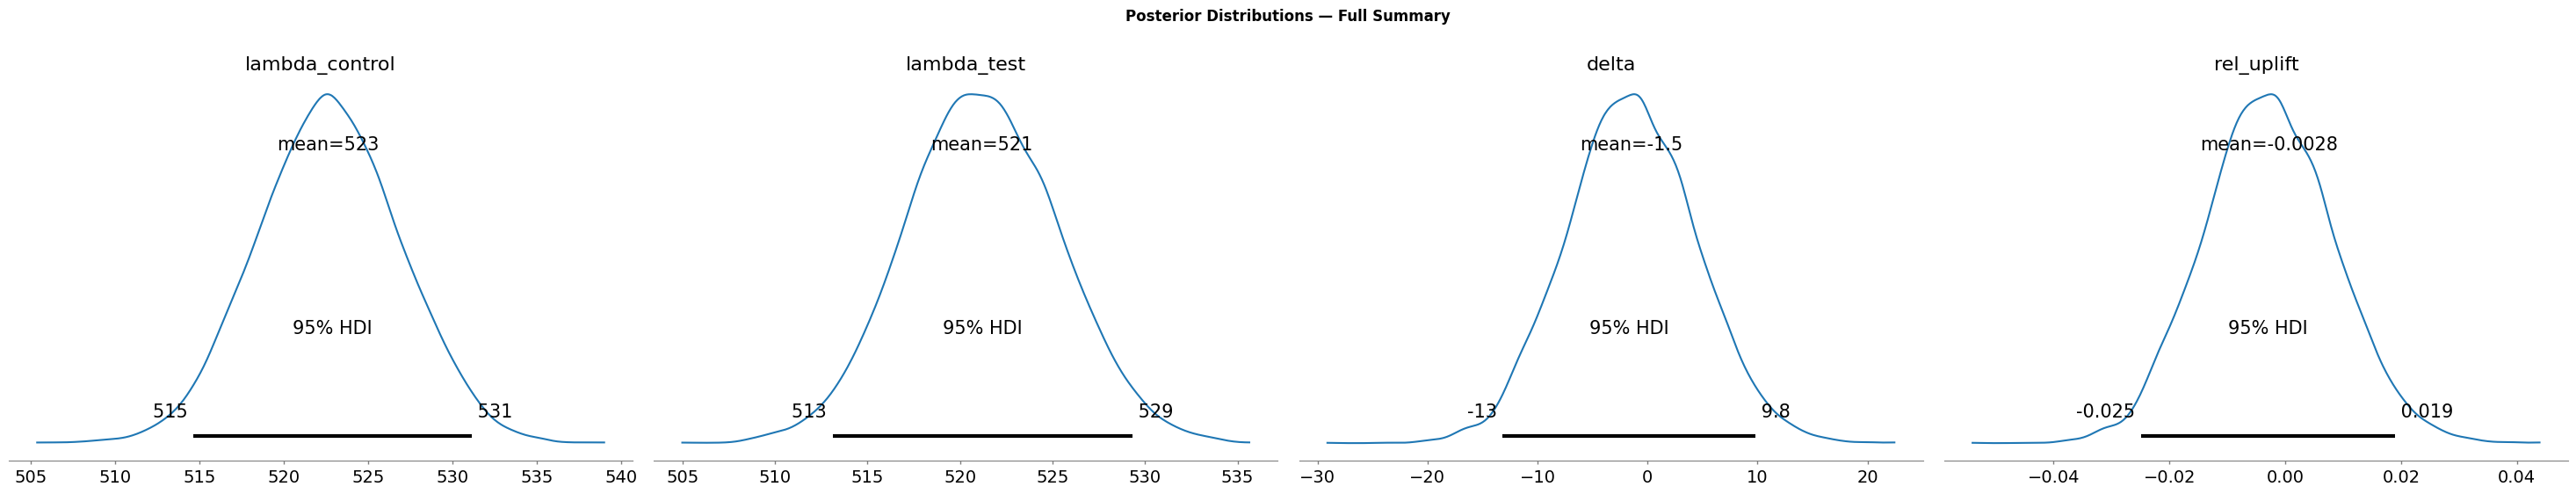

In [34]:
#ArviZ summary for full posterior diagnostics
az.plot_posterior(
    trace,
    var_names=['lambda_control', 'lambda_test', 'delta', 'rel_uplift'],
    hdi_prob=0.95
)
plt.suptitle('Posterior Distributions — Full Summary', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('arviz_posterior_summary.png', dpi=150, bbox_inches='tight')
plt.show()